# 1. Dataset Exploration

In [ ]:
from pathlib import Path

data_dir = Path("../data/raw")

fresh_dir = data_dir / "FreshFish"
infected_dir = data_dir / "InfectedFish"

fresh_images = list(fresh_dir.glob("*")) # collect all the item paths in the folders of fresh fish and infected fish separately, and save them as a list
infected_images = list(infected_dir.glob("*"))

print("FreshFish:", len(fresh_images))
print("InfectedFish:", len(infected_images))

FreshFish: 456
InfectedFish: 752


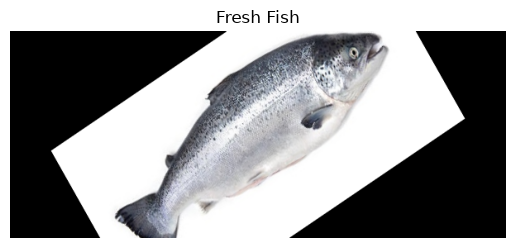

In [2]:
import random
import matplotlib.pyplot as plt
from PIL import Image

sample_path = random.choice(fresh_images)

image = Image.open(sample_path)

plt.imshow(image)
plt.title("Fresh Fish")
plt.axis("off")
plt.show()

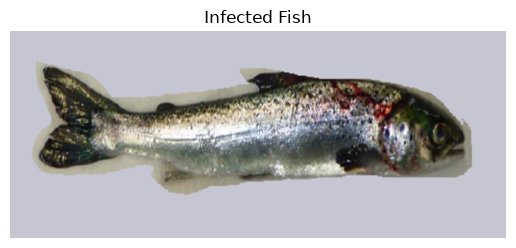

In [3]:
sample_path = random.choice(infected_images)

image = Image.open(sample_path)

plt.imshow(image)
plt.title("Infected Fish")
plt.axis("off")
plt.show()

# 2. Data Preprocessing

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

image_size = 128

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)), # change the size of all images to 128×128 pixels
    transforms.ToTensor(), # convert the image into a digital format that PyTorch can handle
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

dataset = datasets.ImageFolder(
    root="../data/raw",
    transform=transform
)

print(dataset.classes) # ImageFolder will treat each subfolder under the "raw" directory as a category
print(dataset.class_to_idx)
print("Total images:", len(dataset))

['FreshFish', 'InfectedFish']
{'FreshFish': 0, 'InfectedFish': 1}
Total images: 1208


In [9]:
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 845
Validation: 181
Test: 182


In [ ]:
batch_size = 32  # Show 32 pictures to CNN once

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

#iter(train_loader): Creates an iterator that enables you to read the data in batches.
# next(...) Extract the first batch of data from it.
# images, labels = ... Store this batch of data separately into the image variable and the label variable.
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])


32  = batch size,
3   = RGB channels ,
128 = height ,
128 = width 

# 3. Simple CNN Model

### **How to Understand CNN**

RGB Image  
↓  
3 Channels (Red, Green, Blue)  
↓  
Convolution  
提取局部特征  
↓  
Feature Maps  
很多二维数字矩阵  
↓  
ReLU  
加入非线性  
↓  
Pooling  
缩小 feature map 尺寸  
↓  
Convolution  
提取更高级特征  
↓  
Pooling  
继续缩小尺寸  
↓  
Flatten  
把 feature maps 摊平成一个向量  
↓  
Fully Connected Layer  
综合前面提取到的特征  
↓  
Class Scores  
Fresh / Infected

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3, # =3: rgb; inchannels= 1: grey
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # 如果输入特征图是 128×128，经过这一层就变成 64×64，通道数不变。
        self.pool = nn.MaxPool2d(
            kernel_size=2, # 每次看一个 2×2 的区域
            stride=2   # 每次移动 2 格
        )

        # 32 channels, each 32×32
        # ↓ Flatten
        # 32,768 digits (32 × 32 × 32)

        # 把 32768个输入特征，转换成 64个输出特征
        self.fc1 = nn.Linear(
            32 * 32 * 32,
            64
        )
        #把 64个特征转换成2个分类分数
        self.fc2 = nn.Linear(
            64,
            2
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))


        # 32 × 32 × 32
        # ↓
        # Flatten  :Flatten the feature map
        # ↓
        # 32768
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = SimpleCNN()

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


### Model Structure

The model contains two convolutional layers, one max-pooling layer, and two fully connected layers.

- `conv1`: 3 input channels → 16 feature maps
- `conv2`: 16 feature maps → 32 feature maps
- `pool`: reduces the feature-map size by half
- `fc1`: 32768 input features → 64 hidden units
- `fc2`: 64 hidden units → 2 output classes

In [12]:
outputs = model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 2])


# 4. Model Training

In [19]:
import torch.optim as optim

model = SimpleCNN()

criterion = nn.CrossEntropyLoss() #how far off the model's prediction is from the actual category

optimizer = optim.Adam( #Update the parameters in the CNN based on the gradients backpropagated from the loss.
    model.parameters(),
    lr=0.001
)

num_epochs = 10
best_val_loss = float("inf")
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0 #The number of correctly predicted images
    total = 0 # Total number of processed images

    #Read the training data
    for images, labels in train_loader:
        optimizer.zero_grad() #The gradient is used to guide how the model parameters should be adjusted. In PyTorch, gradients are accumulated by default, so the gradients from the previous batch need to be cleared before starting the next batch of training.

        outputs = model(images) # prediction

        loss = criterion(outputs, labels) # caculate loss using nn.CrossEntropyLoss()

        loss.backward() # do backpropagation, figure out how each trainable parameter affects the loss, and then get the gradients.

        optimizer.step()#The optimizer adjusts the parameters based on the gradients. This is where the actual "learning" of the model, i.e., the parameter updates, happens.

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1) # Find the class with the highest score for each image,dim=1 means comparing scores across classes

        total += labels.size(0)# number of images
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

     # Validation
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "../results/best_simple_cnn.pth"
        )
    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Train Acc: {train_accuracy:.4f} "
        f"- Val Loss: {val_loss:.4f} "
        f"- Val Acc: {val_accuracy:.4f}"
    )

Epoch 1/10 - Train Loss: 0.6729 - Train Acc: 0.6178 - Val Loss: 0.4481 - Val Acc: 0.8895
Epoch 2/10 - Train Loss: 0.3953 - Train Acc: 0.8556 - Val Loss: 0.2995 - Val Acc: 0.8840
Epoch 3/10 - Train Loss: 0.2935 - Train Acc: 0.9006 - Val Loss: 0.2698 - Val Acc: 0.9006
Epoch 4/10 - Train Loss: 0.2505 - Train Acc: 0.9065 - Val Loss: 0.1994 - Val Acc: 0.9392
Epoch 5/10 - Train Loss: 0.2236 - Train Acc: 0.8959 - Val Loss: 0.1998 - Val Acc: 0.9392
Epoch 6/10 - Train Loss: 0.1683 - Train Acc: 0.9396 - Val Loss: 0.1845 - Val Acc: 0.9558
Epoch 7/10 - Train Loss: 0.1478 - Train Acc: 0.9444 - Val Loss: 0.1995 - Val Acc: 0.9227
Epoch 8/10 - Train Loss: 0.0965 - Train Acc: 0.9680 - Val Loss: 0.1768 - Val Acc: 0.9503
Epoch 9/10 - Train Loss: 0.0570 - Train Acc: 0.9834 - Val Loss: 0.1718 - Val Acc: 0.9503
Epoch 10/10 - Train Loss: 0.0464 - Train Acc: 0.9893 - Val Loss: 0.1487 - Val Acc: 0.9503


### Training Observation

The training accuracy increased steadily and reached about 99%.

The validation accuracy stayed around 88%–96%.

The best validation accuracy was about 95.6%, while the lowest validation loss occurred at Epoch 10.

The model did not show severe overfitting in this run, although the training accuracy was higher than the validation accuracy.

# 5. Model Evaluation

In [20]:
model = SimpleCNN()

model.load_state_dict(
    torch.load("../results/best_simple_cnn.pth")
)

model.eval()

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

all_labels = []
all_predictions = []

model.eval() #eval() will not automatically calculate the accuracy rate, nor will it shut off the gradient calculation

with torch.no_grad(): # it don't need backpropagation during testing,  turn off gradient calculation to cut down on memory usage and computational overhead 
    for images, labels in test_loader:
        outputs = model(images) # !

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.numpy())

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Test Accuracy: 0.9396
Test Precision: 0.9204
Test Recall: 0.9811
Test F1 Score: 0.9498


### Test Results

The Simple CNN achieved a test accuracy of about 94%.

The recall for the InfectedFish class was about 98%, which means most infected fish were correctly detected.

The precision was about 92%, showing that some fresh fish were incorrectly classified as infected.

Overall, the model achieved a test F1 score of about 0.95.

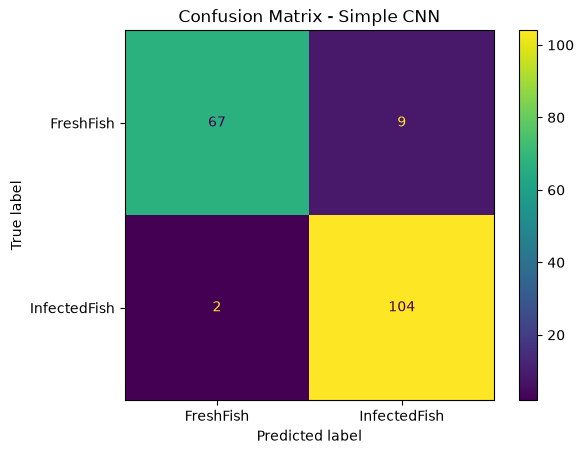

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FreshFish", "InfectedFish"]
)

disp.plot()
plt.title("Confusion Matrix - Simple CNN")
plt.show()

### Confusion Matrix Observation

The model correctly classified 67 fresh fish and 104 infected fish.

Only 2 infected fish were incorrectly classified as fresh, which explains the high recall.

However, 9 fresh fish were incorrectly classified as infected.

This suggests that the model is good at detecting infected fish, but it produces some false alarms for fresh fish.

#### notes
Precision focuses more on false positives (Precision 更关心误报)  
Recall focuses more on missed diagnoses (Recall 更关心漏诊)

# 6. Error Analysis

In [23]:
wrong_indices = [
    i for i, (true, pred) in enumerate(zip(all_labels, all_predictions))
    if true != pred
]

print("Number of misclassified images:", len(wrong_indices))

Number of misclassified images: 11


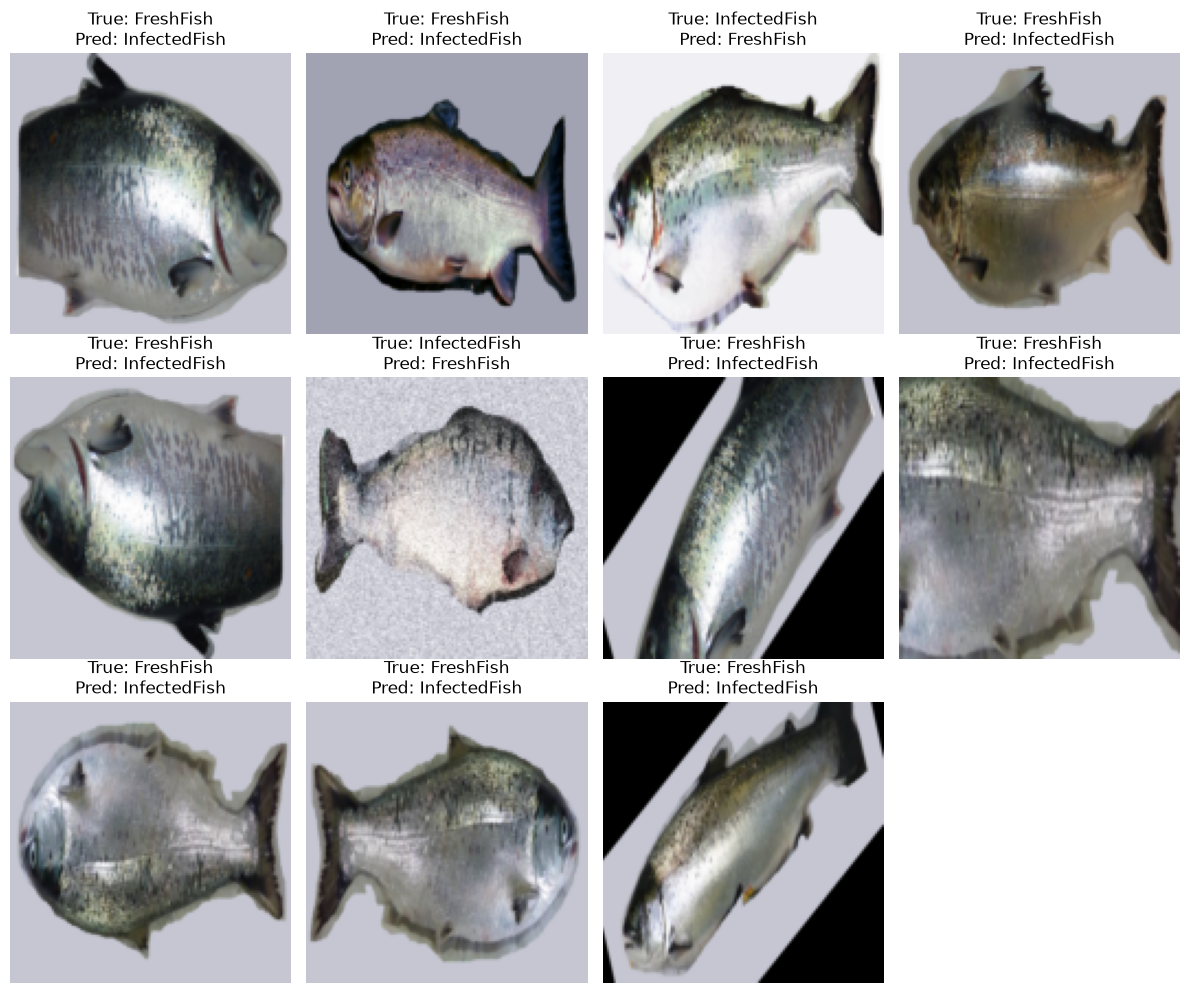

In [24]:
import matplotlib.pyplot as plt

class_names = ["FreshFish", "InfectedFish"]

plt.figure(figsize=(12, 10))

for i, wrong_idx in enumerate(wrong_indices):
    image, true_label = test_dataset[wrong_idx]

    # convert tensor from [C, H, W] to [H, W, C]
    image = image.permute(1, 2, 0)

    # reverse normalization
    image = image * 0.5 + 0.5

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[all_predictions[wrong_idx]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Error Analysis Observation

Some misclassified images look very similar to the opposite class.

Several FreshFish images do not show obvious differences from InfectedFish images, and some infected fish also do not show clear visible symptoms.

This may make the classification task difficult even for human observation.

The model may also be learning other visual patterns such as colour, texture, shape, or background instead of disease-specific features.

# 7. Grad-CAM Visualization

forward  
↓  
得到预测  
  
backward  
↓  
看哪个 feature map 对这个预测最重要  
  
加权组合  
↓  
得到 heatmap  

In [27]:
import torch
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(
            self.save_activation
        )

        self.target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image, class_index=None):
        self.model.eval()

        output = self.model(image)

        if class_index is None:
            class_index = output.argmax(dim=1).item()

        self.model.zero_grad()

        score = output[0, class_index]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (
            weights * self.activations
        ).sum(dim=1)

        cam = torch.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()

        cam = cam - cam.min()

        if cam.max() != 0:
            cam = cam / cam.max()

        return cam, class_index

grad_cam = GradCAM(
    model,
    model.conv2
)

image, true_label = test_dataset[0]

input_image = image.unsqueeze(0)

cam, predicted_class = grad_cam.generate(
    input_image
)



In [28]:
%pip install opencv-python
import cv2

cam_resized = cv2.resize(
    cam,
    (128, 128)
)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   - -------------------------------------- 2.1/44.0 MB 12.5 MB/s eta 0:00:04
   ---- ----------------------------------- 5.2/44.0 MB 14.6 MB/s eta 0:00:03
   ------- -------------------------------- 8.4/44.0 MB 14.6 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/44.0 MB 14.0 MB/s eta 0:00:03
   ------------- -------------------------- 14.4/44.0 MB 14.5 MB/s eta 0:00:03
   ---------------- ----------------------- 18.1/44.0 MB 15.3 MB/s eta 0:00:02
   ------------------- -------------------- 21.5/44.0 MB 15.4 MB/s eta 0:00:02
   ---------------------- ----------------- 24.4/44.0 MB 15.4 MB/s eta 0:00:02
   ------------------------- -------------- 27.8/44.0 MB 15.4 MB/s eta 0:00:02
   ---------------------------- ----------- 31.5/44.0 MB 15.7 MB/s eta 0:00:01
   ------------------------------- -------- 34.6/44.0 MB 15.7 MB/

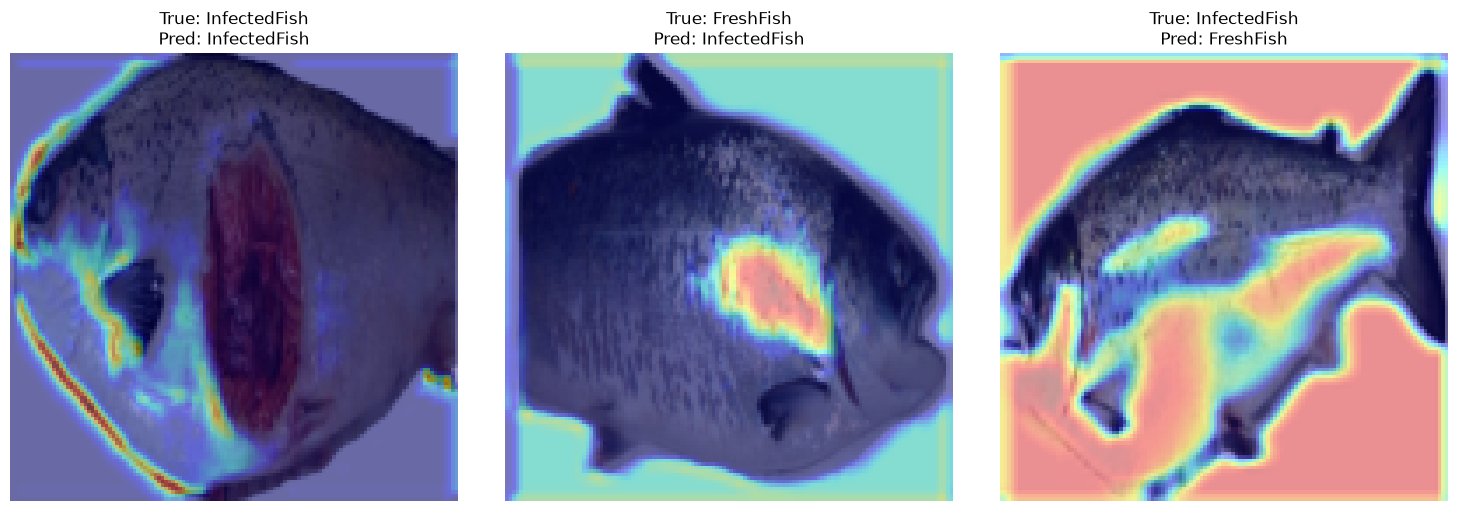

In [30]:
import matplotlib.pyplot as plt

def show_gradcam(image, true_label, predicted_class, cam_resized, ax):
    display_image = image.permute(1, 2, 0).numpy()
    display_image = display_image * 0.5 + 0.5

    ax.imshow(display_image)
    ax.imshow(
        cam_resized,
        cmap="jet",
        alpha=0.4
    )

    ax.set_title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_class]}"
    )

    ax.axis("off")

correct_infected_idx = None
fresh_to_infected_idx = None
infected_to_fresh_idx = None

for i, (true, pred) in enumerate(zip(all_labels, all_predictions)):
    if true == 1 and pred == 1 and correct_infected_idx is None:
        correct_infected_idx = i

    elif true == 0 and pred == 1 and fresh_to_infected_idx is None:
        fresh_to_infected_idx = i

    elif true == 1 and pred == 0 and infected_to_fresh_idx is None:
        infected_to_fresh_idx = i

selected_indices = [
    correct_infected_idx,
    fresh_to_infected_idx,
    infected_to_fresh_idx
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx in zip(axes, selected_indices):
    image, true_label = test_dataset[idx]

    input_image = image.unsqueeze(0)

    cam, predicted_class = grad_cam.generate(
        input_image
    )

    cam_resized = cv2.resize(
        cam,
        (128, 128)
    )

    show_gradcam(
        image,
        true_label,
        predicted_class,
        cam_resized,
        ax
    )

plt.tight_layout()
plt.show()

### Grad-CAM Comparison

The correctly classified infected fish shows strong attention on a local region of the fish body.

For the FreshFish image that was misclassified as infected, the model also focused on a local body region. This suggests that some colour or texture patterns in fresh fish may look similar to the features learned for infected fish.

For the infected fish that was misclassified as fresh, the attention is more spread out and includes some background regions.

These results suggest that the CNN mainly uses fish-body features, but background and non-disease visual patterns may also influence its predictions.

# 8. Limitations

- The dataset is relatively small.

- The numbers of FreshFish and InfectedFish images are not balanced.

- Some fresh and infected fish look very similar, so the classes can be difficult to distinguish visually.

- Grad-CAM shows that the model sometimes focuses on background or non-disease visual patterns.

- The dataset only contains two classes, so the model cannot identify specific fish diseases.
 

# 9. Future Work

Possible future improvements include:

- Using data augmentation to improve model generalisation.
- Comparing the Simple CNN with a transfer-learning model such as **ResNet18**.
- Testing the model on New Zealand Chinook salmon images.
- Extending the task to classify specific fish diseases.
- Using larger and more diverse aquaculture image datasets.
- Exploring anomaly detection using healthy fish images as the normal class.